In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


RAW_DIR= "../data/raw/"
PROCESS_DIR = "../data/processed/"
INTERIM_DIR= "../data/interim/"

# Load both splits UCI provides
train_df = pd.read_csv(os.path.join(RAW_DIR, "drugsComTrain_raw.csv"))
test_df  = pd.read_csv(os.path.join(RAW_DIR, "drugsComTest_raw.csv"))

# Combine — we'll do our own splits later
df = pd.concat([train_df, test_df], ignore_index=True)

print(df.shape)
print(df.columns.tolist())

(215063, 7)
['uniqueID', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount']


In [2]:
df.head(5)

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37


In [3]:
len(df)

215063

In [4]:
df.isnull().sum()
df.dtypes

uniqueID        int64
drugName       object
condition      object
review         object
rating          int64
date           object
usefulCount     int64
dtype: object

C:\Users\HP\AppData\Local\Temp\ipykernel_61796\3800425729.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, palette='viridis')


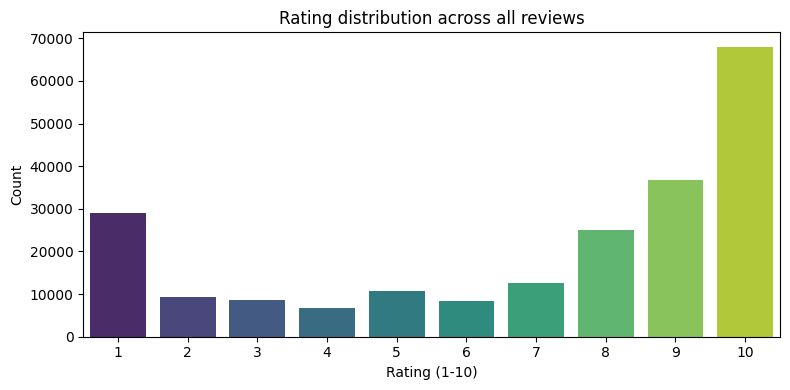

In [5]:
plt.figure(figsize=(8, 4))
sns.countplot(x='rating', data=df, palette='viridis')
plt.title('Rating distribution across all reviews')
plt.xlabel('Rating (1-10)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../outputs/rating_distribution.png', dpi=150)
plt.show()

In [6]:
sample= df.sample(5, random_state=42)[['drugName', 'condition', 'review', 'rating']]
for _, row in sample.iterrows():
    print(f"Drug: {row['drugName']} | Condition: {row['condition']} | Rating: {row['rating']}")
    print(f"Review: {row['review'][:300]}")
    print("-" * 80)

Drug: Acetaminophen / hydrocodone | Condition: Pain | Rating: 9
Review: "I suffered a .45 caliber GSW to the head in 2009. Have had multiple OMFS/ENT surgeries. I have developed a chronic pain condition as a result of the accident. This medication has been a lifesaver. It allows me to function at work and has restored my quality of life. For me, it works significantly b
--------------------------------------------------------------------------------
Drug: Vilazodone | Condition: Major Depressive Disorde | Rating: 1
Review: "I started on Viibryd after having a DNA test done where I found out other medications  aren&#039;t effective for me due to the way my brain processes them. The first week was fine with no symptoms and no noticeable changes. When I went up to 20mg I had terrible crying spells, couldn&#039;t sleep at
--------------------------------------------------------------------------------
Drug: Eluxadoline | Condition: Irritable Bowel Syndrome | Rating: 6
Review: "Not covered 

In [7]:
#clean the text
import re
import html

def clean_review(text):
    if not isinstance(text, str):
        return ""
    text = html.unescape(text)           # fix &#039; → '
    text = re.sub(r'<.*?>', '', text)    # remove any HTML tags
    text = re.sub(r'\s+', ' ', text)     # collapse multiple spaces
    text =text.strip()
    return text
    

df["review_clean"]=df["review"].apply(clean_review)

# Sanity check — compare before and after on one row
idx = df[df['review'].str.contains('&#', na=False)].index[0]
print("BEFORE:", df.loc[idx, 'review'][:800])
print("\nAFTER: ", df.loc[idx, 'review_clean'][:800])

BEFORE: "I used to take another oral contraceptive, which had 21 pill cycle, and was very happy- very light periods, max 5 days, no other side effects. But it contained hormone gestodene, which is not available in US, so I switched to Lybrel, because the ingredients are similar. When my other pills ended, I started Lybrel immediately, on my first day of period, as the instructions said. And the period lasted for two weeks. When taking the second pack- same two weeks. And now, with third pack things got even worse- my third period lasted for two weeks and now it&#039;s the end of the third week- I still have daily brown discharge.
The positive side is that I didn&#039;t have any other side effects. The idea of being period free was so tempting... Alas."

AFTER:  "I used to take another oral contraceptive, which had 21 pill cycle, and was very happy- very light periods, max 5 days, no other side effects. But it contained hormone gestodene, which is not available in US, so I switched to L

In [8]:
# Drop rows with missing condition or empty reviews
df= df.dropna(subset=["condition", "review_clean"])
df= df[df["review_clean"].str.len()>20]  # removing near empty rows
df= df.reset_index(drop=True)

print("Reviews after cleaning:", len(df))


Reviews after cleaning: 212491


In [9]:
# Load SIDER side effect file
sider_path = os.path.join(RAW_DIR, "meddra_all_se.tsv")

sider_df= pd.read_csv(sider_path,
    sep="\t",
    header=None,
    names=["drug_id", "drug_id2", "umls_concept", "meddra_type",
           "umls_concept2", "side_effect_name"])

print(sider_df.shape)
print(sider_df["side_effect_name"].nunique(), "unique side effect terms")
sider_df['side_effect_name'].head(10)


(309849, 6)
6123 unique side effect terms


0         Abdominal cramps
1           Abdominal pain
2           Abdominal pain
3    Gastrointestinal pain
4           Abdominal pain
5                Amblyopia
6                Amblyopia
7                  Anaemia
8                  Anaemia
9                 Anorexia
Name: side_effect_name, dtype: object

In [10]:
# Extract unique side effect terms, lowercase for matching
adr_terms= set(sider_df["side_effect_name"]
            .dropna()
            .str.lower()
            .str.strip()
            .unique()
              )

print(f"Total unique ADR terms in SIDER: {len(adr_terms)}")

# Preview some terms
sorted(list(adr_terms))[:20]

Total unique ADR terms in SIDER: 6123


["5'nucleotidase increased",
 'abasia',
 'abdominal abscess',
 'abdominal adhesions',
 'abdominal aortic aneurysm',
 'abdominal aortic bruit',
 'abdominal aortic rupture',
 'abdominal bloating',
 'abdominal colic',
 'abdominal cramps',
 'abdominal discomfort',
 'abdominal disorder',
 'abdominal distension',
 'abdominal distension gaseous',
 'abdominal distress',
 'abdominal hernia',
 'abdominal infection',
 'abdominal injury',
 'abdominal neoplasm',
 'abdominal pain']

In [ ]:
# This block is discarded as it was taking a long time. 
# The block was was going though the entire adr set for each review.

# def has_adr(review_text, adr_set):
#     """
#     Returns True if any known ADR term appears in the review.
#     Checks multi-word terms too (e.g. 'dry mouth', 'blurred vision').
#     """
#     text_lower= review_text.lower()
#     for value in adr_set:
#         # Use word boundary matching to avoid partial matches
#         pattern = r'\b' + re.escape(value) + r'\b'
#         if re.search(pattern, text_lower):
#             return True
#     return False

# df["has_adr"] = df["review_clean"].apply(lambda x: has_adr(x, adr_terms))

# print("ADR distribution:")
# print(df['has_adr'].value_counts())
# print(f"\nADR rate: {df['has_adr'].mean():.1%}")

In [ ]:
 # This block is discarded as it was taking a long time. 
#The code was compiling all adr terms once to check for patterns in every review text, but still not efficient.

# # Sort longest terms first so "dry mouth" matches before "mouth"
# sorted_terms= sorted(adr_terms, key=len, reverse=True)

# # Join all terms into ONE regex with |
# pattern_str = r'\b(' + '|'.join(re.escape(t) for t in sorted_terms) + r')\b'

# ADR_PATTERN = re.compile(pattern_str, re.IGNORECASE)
# print(f"Pattern compiled from {len(sorted_terms)} terms")

# test= ADR_PATTERN.search("I had severe nausea and headache")
# print("Test match found:", test.group() if test else "None")
# # print(test)

# def has_adr(review_text):
#     return bool(ADR_PATTERN.search(review_text))ADR_PATTERN.search(review_text))

# df["has_adr"]=df["review_clean"].apply(lambda x: has_adr(x))
# print("ADR distribution:")
# print(df['has_adr'].value_counts())
# print(f"\nADR rate: {df['has_adr'].mean():.1%}")

In [11]:
print("Total ADR terms: ", len(adr_terms))

term_lengths= [len(t.split()) for t in adr_terms]
from collections import Counter
print("\nTerm length distribution (words per term):")
for length, count in sorted(Counter(term_lengths).items()):
    print(f"  {length} word(s): {count} terms")

long_terms = [t for t in adr_terms if len(t.split())>3]
print(f"\nTerms longer than 3 words: {len(long_terms)}")
print("Examples:", long_terms[:10])


Total ADR terms:  6123

Term length distribution (words per term):
  1 word(s): 1145 terms
  2 word(s): 3072 terms
  3 word(s): 1505 terms
  4 word(s): 315 terms
  5 word(s): 69 terms
  6 word(s): 6 terms
  7 word(s): 8 terms
  8 word(s): 1 terms
  9 word(s): 1 terms
  10 word(s): 1 terms

Terms longer than 3 words: 401
Examples: ['type iv hypersensitivity reaction', 'international normalised ratio increased', 'arteritic anterior ischaemic optic neuropathy', 'drug - food interaction', 'accidental exposure to product', 'exposure to poisonous plant', 'end stage liver disease', 'band neutrophil count increased', 'blood testosterone free increased', 'tandem gait test abnormal']


In [12]:
import subprocess
subprocess.run(["pip", "install", "pyahocorasick"], check=True)

CompletedProcess(args=['pip', 'install', 'pyahocorasick'], returncode=0)

In [13]:
import ahocorasick

# Filter to reasonable terms only — single and two-word terms cover 95% of real ADRs
# Very long SIDER terms are usually rare procedural descriptions, not patient-reported symptoms
filter_terms= [t for t in adr_terms if len(t.split())<=3]
print("Terms after filtering: ", len(filter_terms))

# Build automaton
A = ahocorasick.Automaton()
for term in filter_terms:
    A.add_word(term, term)
A.make_automaton()

print("Automaton built successfully")

Terms after filtering:  5722
Automaton built successfully


In [14]:
print(A)

In [15]:
def has_adr(review_text):
    text_lower = review_text.lower()
    for _, term in A.iter(text_lower):
        return True
    return False


# Test before applying
print(has_adr("I had severe nausea and headache"))   # should be True
print(has_adr("Great drug, works perfectly fine"))   # should be False

True
False


In [16]:
df["has_adr"]= df["review_clean"].apply(has_adr)

print("ADR distribution:")
print(df['has_adr'].value_counts())
print(f"\nADR rate: {df['has_adr'].mean():.1%}")


ADR distribution:
has_adr
True     166612
False     45879
Name: count, dtype: int64

ADR rate: 78.4%


In [22]:
# def create_bio_labels(review_text, adr_set):
#     """
#     Tokenizes review at word level and assigns BIO tags.
    
#     Returns:
#         words  : list of word strings
#         labels : list of BIO tags (B-ADR, I-ADR, O)
    
#     Strategy:
#         - For each position, check if a known ADR term starts here
#         - Prefer longer matches (dry mouth > mouth)
#         - Multi-word terms get B-ADR on first word, I-ADR on rest
#     """
#     text_lower= review_text.lower()
#     words= review_text.split()
#     words_lower= text_lower.split()
#     labels= ['O'] * len(words)

#     i=0
#     while i < len(words_lower):
#         matched = False

#         # Try longest match first (greedy) — avoids labeling just 'dry'
#         # when 'dry mouth' is a known term
#         for term in sorted(adr_set, key=len, reverse = True):
#             term_words= term.split()
#             term_len= len(term_words)

#             # Check if term fits starting at position i
#             if i + term_len <= len(words_lower):
#                 window= words_lower[i:i+term_len]
#                 # Strip punctuation from window words for matching
#                 window_clean = [re.sub(r'[^a-z]', '', w) for w in window]

#                 if window_clean == term_words:
#                      # Match found, assign BIO tags
#                     labels[i] = 'B-ADR'
#                     for j in range(1, term_len):
#                         labels[i + j] = 'I-ADR'
#                     i += term_len
#                     matched = True
#                     break
        
#         if not matched:
#             i+=1
#     return words, labels

In [17]:
import nltk
nltk.download("punkt_tab") # for tokenization
from nltk.tokenize import word_tokenize

def create_bio_labels(review_text):
    
    # words= review_text.split()
    
    # Replace naive .split() with proper word tokenization
    # nltk splits "nausea." → ['nausea', '.']  cleanly
    words = word_tokenize(review_text)
    # Filter out pure punctuation tokens — we don't need them for NER
    words = [w for w in words if re.search(r'[a-zA-Z0-9]', w)]
    text_lower= review_text.lower()
    labels = ["O"] * len(words)

    # Build character-to-word-index mapping once
    # We need to know: character position X → which word index is it?
    chr_to_word = {}
    chr_idx = 0
    for word_idx, word in enumerate(words):
        for _ in word:
            chr_to_word[chr_idx]= word_idx
            chr_idx += 1
        chr_idx += 1  # for the space between words

    # Single pass — automaton returns (end_char_idx, matched_term)
    for end_idx, term in A.iter(review_text):
        start_idx= end_idx - len(term) + 1

        # Verify word boundaries — avoid matching inside another word
        before_ok = (start_idx == 0 or text_lower[start_idx - 1] == ' ')
        after_ok  = (end_idx + 1 >= len(text_lower) or text_lower[end_idx + 1] == ' ')

        if not before_ok and after_ok:
            continue
            
        # Map character positions to word indices
        if start_idx not in chr_to_word:
            continue

        start_word= chr_to_word[start_idx]
        term_word_count = len(term.split())

        # Assign BIO tags
        labels[start_word] = 'B-ADR'
        for j in range(1, term_word_count):
            if start_word + j < len(labels):
                labels[start_word + j] = 'I-ADR'

    return words, labels

        
    

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [18]:
# testing this function on a dummy constructed example

review_text = "I had severe nausea and dry mouth after taking this drug"
words, labels= create_bio_labels(review_text)

for word, label in zip(words, labels):
    print(f"{word:<20} {label}")

I                    O
had                  O
severe               O
nausea               B-ADR
and                  O
dry                  B-ADR
mouth                I-ADR
after                O
taking               O
this                 O
drug                 O


In [19]:
# applying this to a small sample of our dataset
# Filter to reviews with ADR present (more useful for NER training)

adr_df= df[df["has_adr"]== True].copy()

print(f"Reviews with at least one ADR: {len(adr_df)}")

# Sample 30,000 for our working dataset, enough to train, fast enough to iterate
SAMPLE_SIZE = 30000
sample_df = adr_df.sample(
    min(SAMPLE_SIZE, len(adr_df)),
    random_state=42
).reset_index(drop=True)

print(f"Working sample size: {len(sample_df)}")

Reviews with at least one ADR: 166612
Working sample size: 30000


In [20]:
print("Creating BIO labels... ")

bio_results= sample_df["review_clean"].apply(create_bio_labels)

sample_df['words']  = bio_results.apply(lambda x: x[0])
sample_df['labels'] = bio_results.apply(lambda x: x[1])

# Sanity check - label distribution
all_labels = [l for labels in sample_df['labels'] for l in labels]
from collections import Counter
label_counts = Counter(all_labels)
print("\nLabel distribution across all tokens:")
for label, count in sorted(label_counts.items()):
    pct = count / len(all_labels) * 100
    print(f"  {label:<8} {count:>8,}  ({pct:.1f}%)")

Creating BIO labels... 

Label distribution across all tokens:
  B-ADR      75,132  (2.7%)
  I-ADR       8,051  (0.3%)
  O        2,743,681  (97.1%)


In [21]:
df

,uniqueID,drugName,condition,review,rating,date,usefulCount,review_clean,has_adr
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27,"""It has no side effect, I take it in combinati...",False
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192,"""My son is halfway through his fourth week of ...",True
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17,"""I used to take another oral contraceptive, wh...",False
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10,"""This is my first time using any form of birth...",False
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37,"""Suboxone has completely turned my life around...",True
...,...,...,...,...,...,...,...,...,...
212486,123432,Apri,Birth Control,"""I started taking Apri about 7 months ago. My ...",9,25-Aug-10,18,"""I started taking Apri about 7 months ago. My ...",True
212487,159999,Tamoxifen,"Breast Cancer, Prevention","""I have taken Tamoxifen for 5 years. Side effe...",10,13-Sep-14,43,"""I have taken Tamoxifen for 5 years. Side effe...",True
212488,140714,Escitalopram,Anxiety,"""I&#039;ve been taking Lexapro (escitaploprgra...",9,8-Oct-16,11,"""I've been taking Lexapro (escitaploprgram) si...",True
212489,130945,Levonorgestrel,Birth Control,"""I&#039;m married, 34 years old and I have no ...",8,15-Nov-10,7,"""I'm married, 34 years old and I have no kids....",True


In [22]:
# save the file to data/processed folder
import json

# Save the binary-labeled full cleaned df
df.to_csv(os.path.join(PROCESS_DIR, "reviews_binary_labeled.csv"), index=False)

# Save the BIO-labeled sample as JSON (preserves list structure cleanly)
bio_records=[]
for _, row in sample_df.iterrows():
    bio_records.append({
        "drug": row['drugName'],
        "condition": row['condition'],
        "rating": row['rating'],
        "review": row['review_clean'],
        "words": row['words'],
        "labels": row['labels']
    })

with open(os.path.join(PROCESS_DIR, "bio_labeled_sample.json"), "w") as f:
    json.dump(bio_records, f, indent=2)

print(f"Saved {len(bio_records)} BIO-labeled records")
print(f"Saved {len(df)} binary-labeled records")

Saved 30000 BIO-labeled records
Saved 212491 binary-labeled records


In [23]:
# testing if cleaning was correcct
test = '"Worked fine for 2 days - burning and itching returned on day 3."'
words = word_tokenize(test)
words_filtered = [w for w in words if re.search(r'[a-zA-Z0-9]', w)]
print("Raw split:  ", test.split())
print("NLTK clean: ", words_filtered)

Raw split:   ['"Worked', 'fine', 'for', '2', 'days', '-', 'burning', 'and', 'itching', 'returned', 'on', 'day', '3."']
NLTK clean:  ['Worked', 'fine', 'for', '2', 'days', 'burning', 'and', 'itching', 'returned', 'on', 'day', '3']
